In [38]:
import pandas as pd 
import numpy as np 
from sklearn.model_selection import train_test_split 
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

In [39]:
data = pd.read_csv(r"C:\Users\KOIN\Downloads\titanic (1).csv")
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,0,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,1,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,0,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,0,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,1,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


In [40]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [41]:
data = data[[ 'Survived', 'Pclass', 'Sex', 'Age', 'SibSp',
       'Parch', 'Fare', 'Embarked']]
data.dropna(inplace=True)

data["Age"].fillna(data["Age"].mean() , inplace=True)
data["Embarked"].fillna(data["Embarked"].mode()[0] , inplace=True)
data["Fare"].fillna(data["Fare"].median(), inplace=True)

data = pd.get_dummies(data , columns=["Sex" , "Embarked"] , drop_first=True)

data

C:\Users\KOIN\AppData\Local\Temp\ipykernel_20468\2084774380.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  data["Age"].fillna(data["Age"].mean() , inplace=True)
C:\Users\KOIN\AppData\Local\Temp\ipykernel_20468\2084774380.py:6: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For 

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,34.5,0,0,7.8292,True,True,False
1,1,3,47.0,1,0,7.0000,False,False,True
2,0,2,62.0,0,0,9.6875,True,True,False
3,0,3,27.0,0,0,8.6625,True,False,True
4,1,3,22.0,1,1,12.2875,False,False,True
...,...,...,...,...,...,...,...,...,...
409,1,3,3.0,1,1,13.7750,False,False,True
411,1,1,37.0,1,0,90.0000,False,True,False
412,1,3,28.0,0,0,7.7750,False,False,True
414,1,1,39.0,0,0,108.9000,False,False,False


In [42]:
data.columns

Index(['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Sex_male',
       'Embarked_Q', 'Embarked_S'],
      dtype='object')

In [47]:
x= data.drop(columns="Survived",axis=1)
y  = data["Survived"]
X

,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,3,34.5,0,0,7.8292,True,True,False
1,3,47.0,1,0,7.0000,False,False,True
2,2,62.0,0,0,9.6875,True,True,False
3,3,27.0,0,0,8.6625,True,False,True
4,3,22.0,1,1,12.2875,False,False,True
...,...,...,...,...,...,...,...,...
409,3,3.0,1,1,13.7750,False,False,True
411,1,37.0,1,0,90.0000,False,True,False
412,3,28.0,0,0,7.7750,False,False,True
414,1,39.0,0,0,108.9000,False,False,False


In [48]:
x_train , x_test , y_train , y_test = train_test_split(x,y, test_size=0.2 , random_state=42)

In [50]:
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [58]:
def create_model():
    model = Sequential()

    model.add(Dense(32 , input_dim = x_train.shape[1] , activation="relu"))
    model.add(Dense(16 , activation="relu"))
    model.add(Dense(1 , activation="sigmoid"))

    return model

In [79]:
moment_model = create_model()
momentum_opt = SGD(learning_rate=0.01 , momentum=0.9)


moment_model.compile(optimizer = momentum_opt , loss = "binary_crossentropy" , metrics=["accuracy"] )

history_moment = moment_model.fit(x_train , y_train , validation_data=(x_test , y_test) , epochs=100 , batch_size=32 , verbose=0)



In [81]:
model_nag = create_model()
nag_opt = SGD(learning_rate=0.01 , momentum=0.9 , nesterov=True)

model_nag.compile(optimizer = nag_opt , loss = "binary_crossentropy" , metrics=["accuracy"])

history_nag = model_nag.fit(x_train , y_train  , validation_data= (x_test , y_test) , epochs=100 , batch_size=32 , verbose=0)

In [69]:
import matplotlib.pyplot as plt

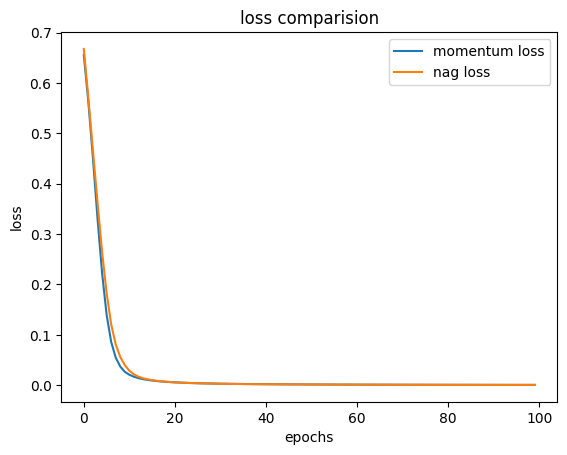

In [88]:
plt.plot(history_moment.history["loss"] , label= "momentum loss")
plt.plot(history_nag.history["loss"] , label="nag loss")

plt.title("loss comparision")
plt.xlabel("epochs")
plt.ylabel("loss")
plt.legend()
plt.show()


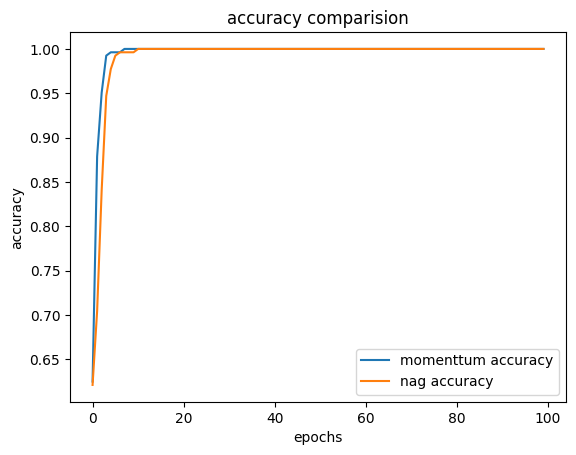

In [89]:
plt.plot(history_moment.history["accuracy"] , label= "momenttum accuracy")
plt.plot(history_nag.history["accuracy"] , label="nag accuracy")

plt.title("accuracy comparision")
plt.xlabel("epochs")
plt.ylabel("accuracy")
plt.legend()
plt.show()